In [1]:
import pandas as pd

# Load the dataset
# Doubt: why first load the CSV?
# Answer: before any ML step, we need the raw data in a dataframe so we can inspect, clean, split, and model it.
df = pd.read_csv("weight-height.csv")

# Check whether the file loaded correctly
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [2]:
# Quick structural check
df.shape

(10000, 3)

In [3]:
# See summary statistics
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


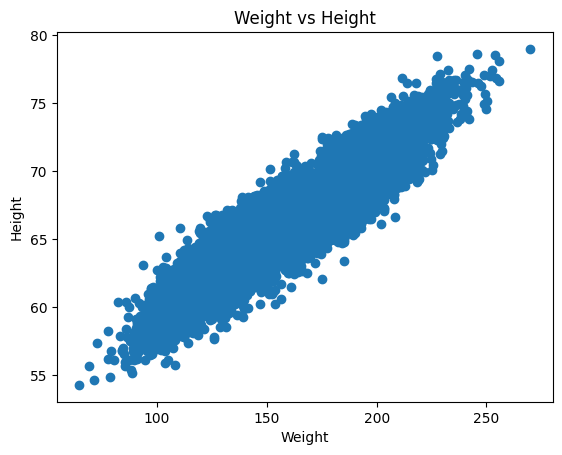

In [4]:
import matplotlib.pyplot as plt

# Scatter plot to see whether linear regression is a good idea
# Doubt: why do we plot before modeling?
# Answer: because SLR only makes sense when the relationship looks approximately linear.
plt.scatter(df["Weight"], df["Height"])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Weight vs Height")
plt.show()

In [5]:
# Problem statement:
# predict Height based on Weight

# X = input feature(s)
# Y = target/output
# Doubt: why X is double bracket?
# Answer: df[["Weight"]] gives a DataFrame (2D), which sklearn expects for X.
X = df[["Weight"]]
Y = df[["Height"]]

print(X.head())
print(Y.head())

       Weight
0  241.893563
1  162.310473
2  212.740856
3  220.042470
4  206.349801
      Height
0  73.847017
1  68.781904
2  74.110105
3  71.730978
4  69.881796


In [6]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
# Doubt: why split data?
# Answer: train data is for learning, test data is for checking how well the model performs on unseen data.
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=1
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape :", Y_test.shape)

X_train shape: (7500, 1)
X_test shape : (2500, 1)
Y_train shape: (7500, 1)
Y_test shape : (2500, 1)


In [7]:
# Standard scaling
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Doubt: why scale after train-test split?
# Answer: fit only on training data to avoid data leakage.
# If we fit on test data, the model indirectly learns information from unseen data.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])
print(X_test_scaled[:5])

[[ 1.77184085]
 [-0.91828697]
 [-0.80808982]
 [ 0.29154082]
 [-0.99141854]]
[[-0.90971458]
 [ 0.92023228]
 [ 1.04600884]
 [ 0.38669006]
 [-0.24557   ]]


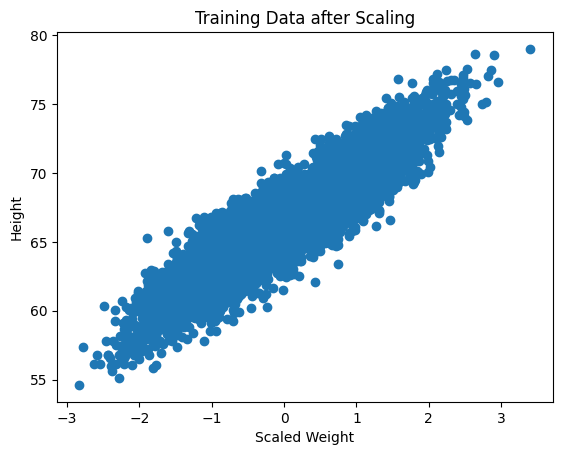

In [8]:
import matplotlib.pyplot as plt

# This plot shows Weight after standard scaling
# X-axis values are now in standard deviation units, not raw weight units.
plt.scatter(X_train_scaled, Y_train)
plt.xlabel("Scaled Weight")
plt.ylabel("Height")
plt.title("Training Data after Scaling")
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression

# Create the regression model
# Doubt: what does this line do?
# Answer: it only creates the model object. No training happens yet.
regressor = LinearRegression()

regressor

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Train the model on scaled training inputs and training targets
# Doubt: why use X_train_scaled and not X_test_scaled?
# Answer: test data must stay hidden during training; otherwise the evaluation becomes fake.
regressor.fit(X_train_scaled, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
# Slope / coefficient
regressor.coef_

array([[3.50752018]])

In [12]:
# Intercept
regressor.intercept_

array([66.39100378])

In [13]:
# Learnable equation for your model:
# Height = 3.5075 * (Scaled Weight) + 66.3910

In [14]:
# Predict on unseen test data
# Doubt: why do we use X_test_scaled here?
# Answer: because the model was trained on scaled input, so the test input must be transformed the same way.
Y_test_pred = regressor.predict(X_test_scaled)

Y_test_pred[:5]

array([[63.20016153],
       [69.61873707],
       [70.05990088],
       [67.74732698],
       [65.52966206]])

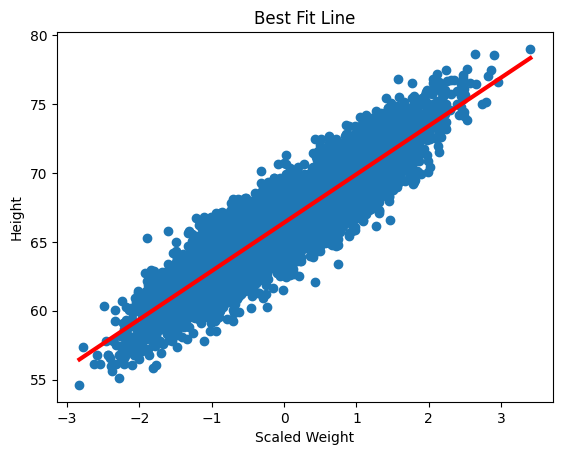

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the training points
plt.scatter(X_train_scaled, Y_train)

# Sort X values so the line appears properly from left to right
# Doubt: why sort?
# Answer: matplotlib joins points in order. Sorting avoids a zig-zag looking line.
x_line = np.sort(X_train_scaled, axis=0)

# Predict values on the sorted X values
y_line = regressor.predict(x_line)

# Best fit line
plt.plot(x_line, y_line, color="red", linewidth=3)

plt.xlabel("Scaled Weight")
plt.ylabel("Height")
plt.title("Best Fit Line")
plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compare actual test values with predicted values
mae = mean_absolute_error(Y_test, Y_test_pred)
mse = mean_squared_error(Y_test, Y_test_pred)
r2 = r2_score(Y_test, Y_test_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 :", r2)

MAE: 1.1661577869850313
MSE: 2.12446421230536
R2 : 0.865879095003058


In [17]:
# Adjusted R²
# Doubt: why use adjusted R²?
# Answer: it penalizes unnecessary features. In simple linear regression, it is almost the same as R².
n = X_test_scaled.shape[0]   # number of rows
p = X_test_scaled.shape[1]   # number of features

adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

print("Adjusted R²:", adjusted_r2)

Adjusted R²: 0.8658254036880072


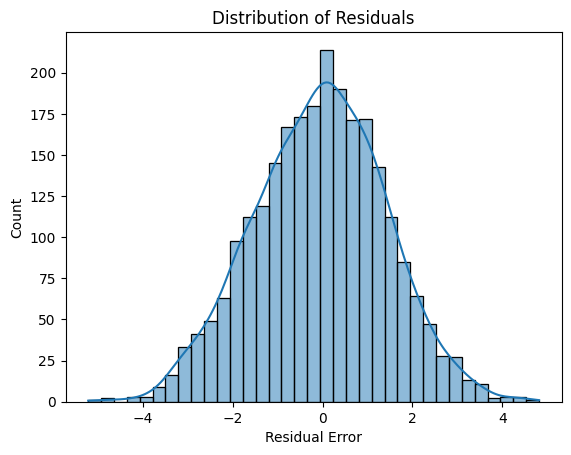

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Residuals = actual - predicted
# Doubt: why actual minus predicted?
# Answer: residual tells us how far the model missed the true value.
error = Y_test.values.ravel() - Y_test_pred.ravel()

sns.histplot(error, kde=True)
plt.xlabel("Residual Error")
plt.title("Distribution of Residuals")
plt.show()

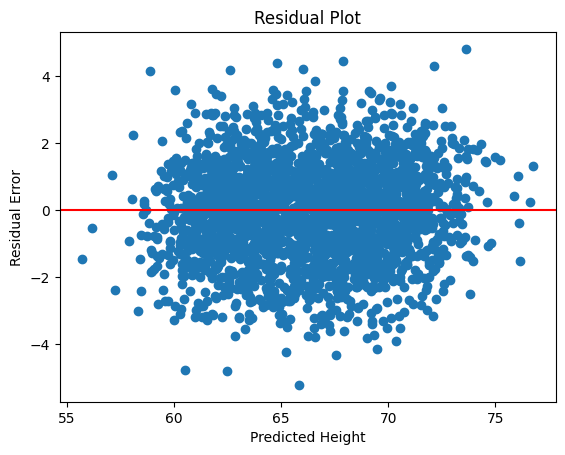

In [19]:
import matplotlib.pyplot as plt

# Residual plot is more useful than only the histogram
plt.scatter(Y_test_pred, error)
plt.axhline(y=0, color="red")

plt.xlabel("Predicted Height")
plt.ylabel("Residual Error")
plt.title("Residual Plot")
plt.show()

In [20]:
# Example: predict height for one new weight value
# Important: new input must also be scaled using the same scaler
new_weight = [[150]]   # raw weight value

new_weight_scaled = scaler.transform(new_weight)
predicted_height = regressor.predict(new_weight_scaled)

print("Predicted height:", predicted_height[0][0])

Predicted height: 65.1233732004838


c:\Users\parth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
